In [20]:
import numpy as np
import pandas as pd
from jcopml.automl import AutoClassifier

In [21]:
df = pd.read_csv("data/prediksi_gagal_jantung.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


# Daset spliting


In [22]:
X = df.drop(columns="DEATH_EVENT")
y = df["DEATH_EVENT"]


# Training

In [23]:
model = AutoClassifier(["age","creatinine_phosphokinase","ejection_fraction","platelets","serum_creatinine","serum_sodium","time"],["anaemia","diabetes","high_blood_pressure","smoking"])
model.fit(X,y,cv=5)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
================== Best Model Info ==================
algo                      | XGBClassifier
algo__colsample_bytree    | 0.9556428757689247
algo__gamma               | 8
algo__learning_rate       | 0.1575132049977973
algo__max_depth           | 7
algo__n_estimators        | 182
algo__reg_alpha           | 0.0025113061677390002
algo__reg_lambda          | 0.06870614282613305
algo__subsample           | 0.4668543055695109

================================ Best Preprocessor Info =================================
categorical_imputer       | SimpleImputer(add_indicator=False, strategy='most_frequent')
categorical_encoder       | OneHotEncoder
numerical_imputer         | SimpleImputer(add_indicator=False, strategy='median')
numerical_scaler          | RobustScaler

=========== Score ===========
Train: 0.8891415794066317
Valid: 0.8618794326241135
Test : 0.85


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2885: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


# View Result / Hasil dari tuningnya

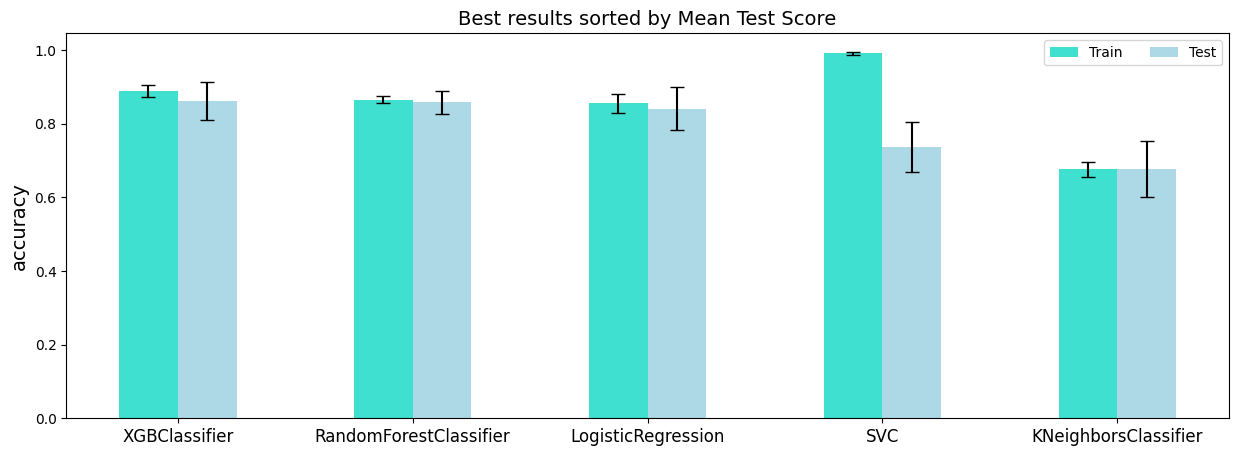

In [24]:
model.plot_results()

# kita cek feture importancenya

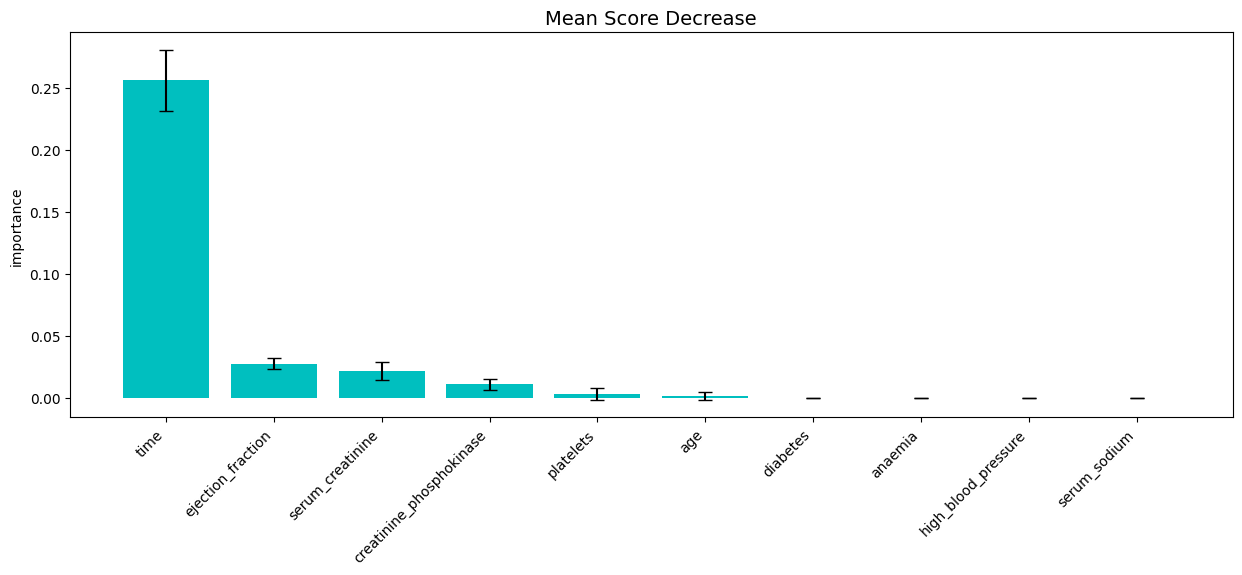

In [25]:
model.mean_score_decrease()

# setelah kita mendpatkan bahwa xgboost yang terbaik maka kita akan fokus ke xgboost saja

In [27]:
model.fit(X,y,cv=5,algo=["xgb"],n_trial=100)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
================== Best Model Info ==================
algo                      | XGBClassifier
algo__colsample_bytree    | 0.4086341778504343
algo__gamma               | 9
algo__learning_rate       | 0.2281416815699846
algo__max_depth           | 3
algo__n_estimators        | 117
algo__reg_alpha           | 0.002226799690893868
algo__reg_lambda          | 0.14074279366401693
algo__subsample           | 0.5934205590104396

================================ Best Preprocessor Info =================================
categorical_imputer       | SimpleImputer(add_indicator=False, strategy='most_frequent')
categorical_encoder       | OneHotEncoder
numerical_imputer         | SimpleImputer(add_indicator=False, strategy='median')
numerical_scaler          | RobustScaler

=========== Score ===========
Train: 0.8859784031413612
Valid: 0.8828900709219857
Test : 0.8
